# **02. SQL Analysis of clean dataset**

In [1]:
import sys
sys.path.append('../src')
from models import SalesRecord, ReturnRecord, Invoice

import pandas as pd
import sqlite3
from sqlalchemy import create_engine

In [2]:
import matplotlib.pyplot as plt

In [3]:
df_sales = pd.read_csv("../data/sales_clean.csv")
df_returns = pd.read_csv("../data/returns_clean.csv")

In [4]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17946

## 2.1 Exploring revenue throughout months

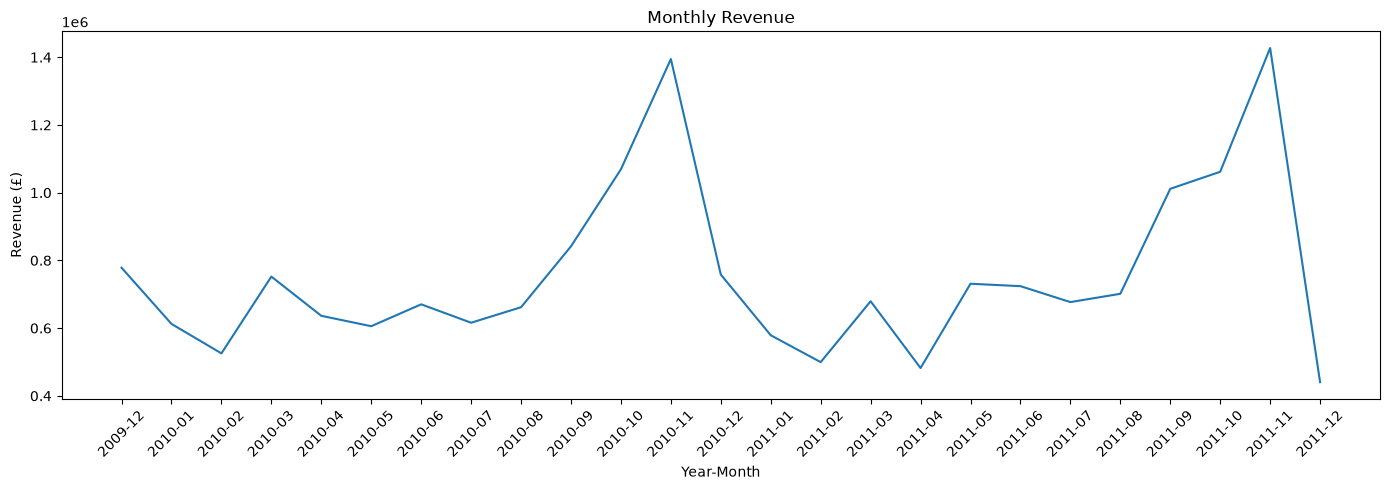

In [ ]:
query = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """
df_revenue = pd.read_sql(query,engine)

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_revenue["year_month"], df_revenue["revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()


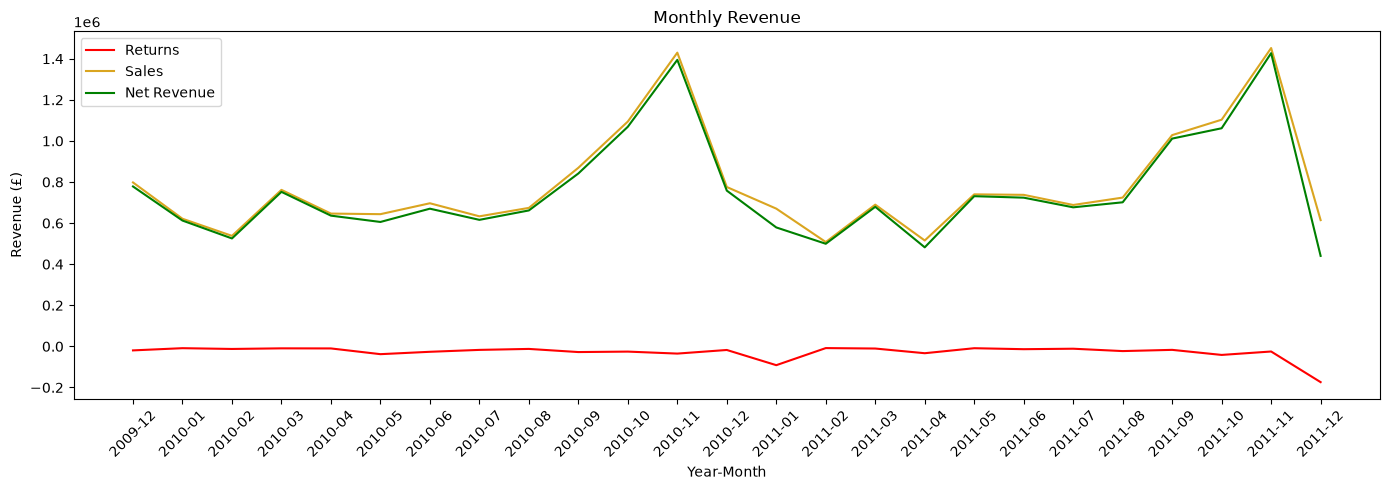

In [22]:
query_1 = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM returns
    GROUP BY year_month
    ORDER BY year_month
    """

query_2 = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """
df_returns = pd.read_sql(query_1,engine)
df_sales = pd.read_sql(query_2,engine)

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_returns["year_month"], df_returns["revenue"],c="red", label="Returns")
plt.plot(df_sales["year_month"], df_sales["revenue"],c="goldenrod", label="Sales")
plt.plot(df_revenue["year_month"], df_revenue["revenue"],c="green", label="Net Revenue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

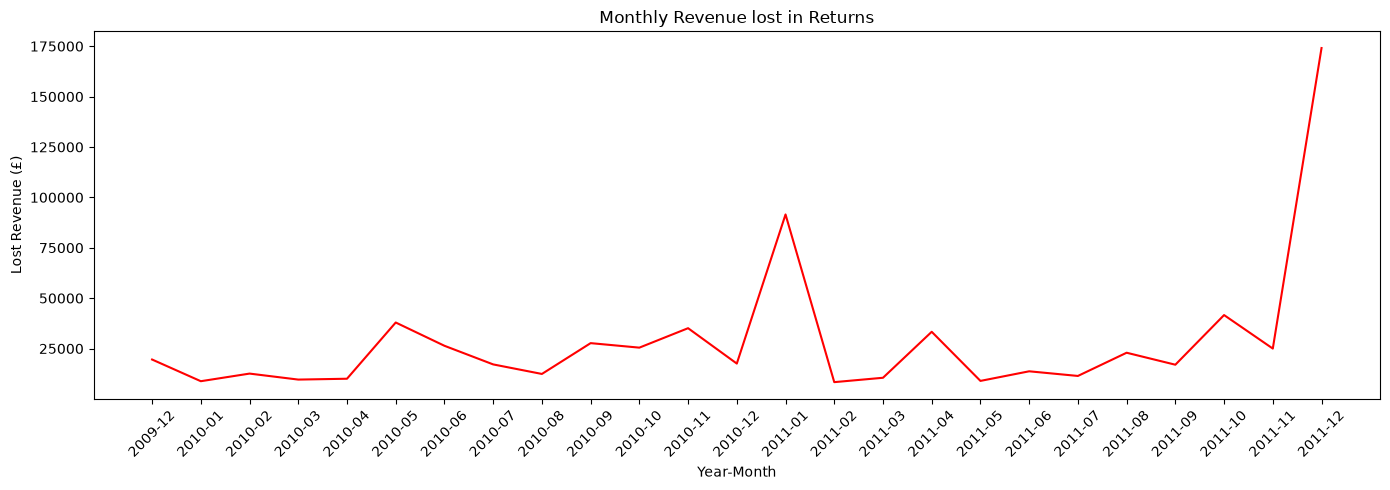

In [23]:
plt.figure(figsize=(14,5))
plt.plot(df_returns["year_month"], -df_returns["revenue"],c="red", label="Returns")
plt.xticks(rotation=45)
plt.title("Monthly Revenue lost in Returns")
plt.xlabel("Year-Month")
plt.ylabel("Lost Revenue (£)")
plt.tight_layout()
plt.show()

## 2.2 Exploring revenue per Country